In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [ ]:
DATA_ROOT = r"C:\Users\Haoha\Desktop\archive\COVID-19_Radiography_Dataset"

In [ ]:
CLASS_NAMES = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASS_NAMES)}
CLASS_TO_IDX

{'COVID': 0, 'Lung_Opacity': 1, 'Normal': 2, 'Viral Pneumonia': 3}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'COVID-19_Radiography_Dataset.zip', 'archive.zip']


In [ ]:
!unzip -q "/content/drive/MyDrive/archive.zip" -d /content/data

In [ ]:
import os

print(os.listdir('/content/data'))

['COVID-19_Radiography_Dataset']


In [ ]:
DATA_ROOT = "/content/data/COVID-19_Radiography_Dataset"

In [ ]:
import os

CLASS_NAMES = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]

for cls in CLASS_NAMES:
    img_dir = os.path.join(DATA_ROOT, cls, "images")
    print(cls, "->", img_dir, "exists:", os.path.exists(img_dir))

COVID -> /content/data/COVID-19_Radiography_Dataset/COVID/images exists: True
Lung_Opacity -> /content/data/COVID-19_Radiography_Dataset/Lung_Opacity/images exists: True
Normal -> /content/data/COVID-19_Radiography_Dataset/Normal/images exists: True
Viral Pneumonia -> /content/data/COVID-19_Radiography_Dataset/Viral Pneumonia/images exists: True


In [ ]:
def collect_image_paths(data_root, class_names):
    rows = []
    for cls in class_names:
        img_dir = os.path.join(data_root, cls, "images")
        if not os.path.exists(img_dir):
            raise FileNotFoundError(f"Cannot find image folder: {img_dir}")

        for fname in os.listdir(img_dir):
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                rows.append({
                    "filepath": os.path.join(img_dir, fname),
                    "label_name": cls,
                    "label": CLASS_TO_IDX[cls]
                })
    return pd.DataFrame(rows)

df = collect_image_paths(DATA_ROOT, CLASS_NAMES)
print(df.head())
print("Total images:", len(df))
print(df["label_name"].value_counts())

                                            filepath label_name  label
0  /content/data/COVID-19_Radiography_Dataset/COV...      COVID      0
1  /content/data/COVID-19_Radiography_Dataset/COV...      COVID      0
2  /content/data/COVID-19_Radiography_Dataset/COV...      COVID      0
3  /content/data/COVID-19_Radiography_Dataset/COV...      COVID      0
4  /content/data/COVID-19_Radiography_Dataset/COV...      COVID      0
Total images: 21165
label_name
Normal             10192
Lung_Opacity        6012
COVID               3616
Viral Pneumonia     1345
Name: count, dtype: int64


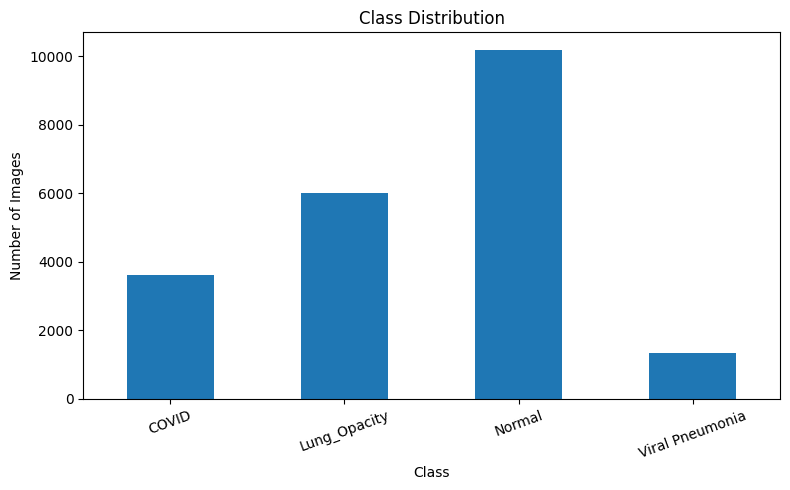

label_name
COVID               3616
Lung_Opacity        6012
Normal             10192
Viral Pneumonia     1345
Name: count, dtype: int64
Class proportions:
label_name
COVID              0.1708
Lung_Opacity       0.2841
Normal             0.4815
Viral Pneumonia    0.0635
Name: count, dtype: float64


In [ ]:
class_counts = df["label_name"].value_counts().reindex(CLASS_NAMES)

plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print(class_counts)
print("Class proportions:")
print((class_counts / class_counts.sum()).round(4))

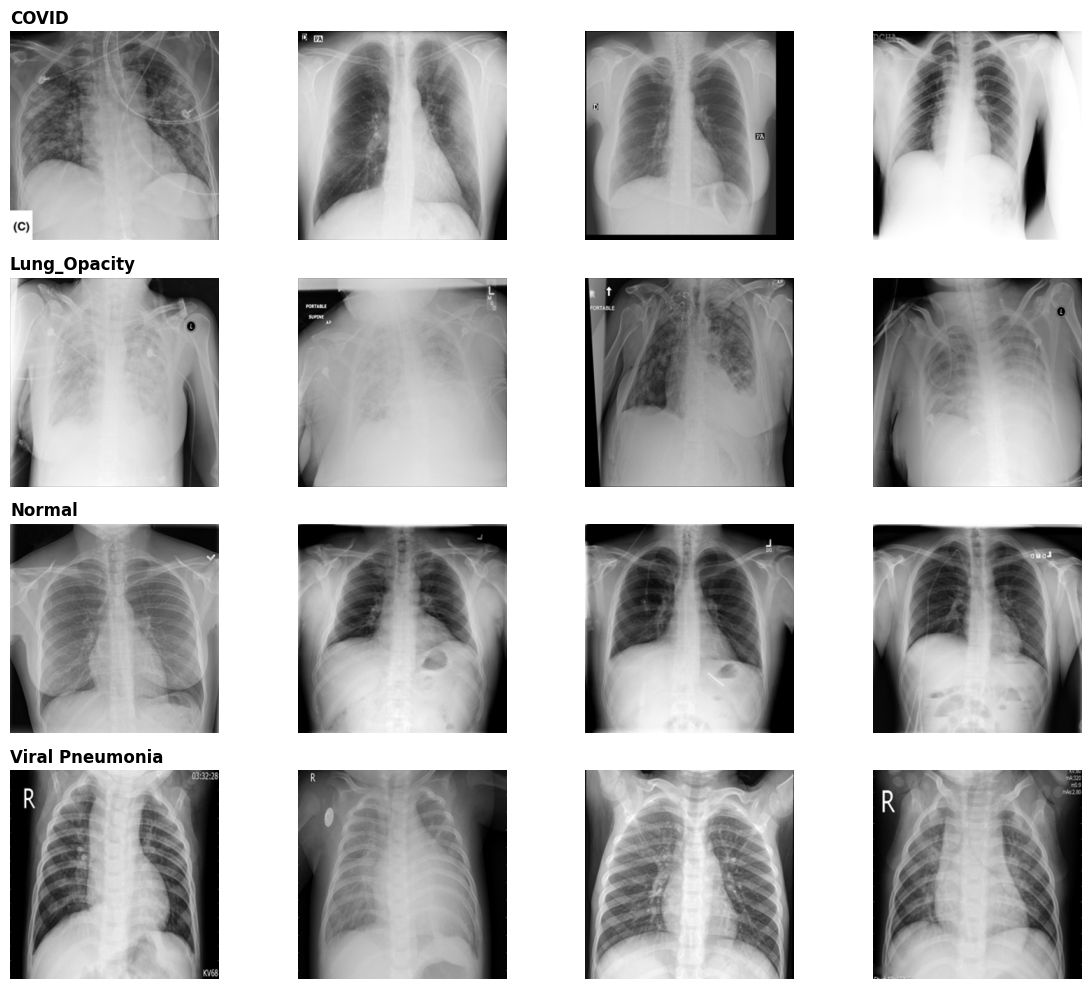

In [ ]:
def show_samples(df, class_names, n_per_class=4, figsize=(12, 10)):
    fig, axes = plt.subplots(len(class_names), n_per_class, figsize=figsize)

    for i, cls in enumerate(class_names):
        subset = df[df["label_name"] == cls].sample(n=n_per_class, random_state=SEED)
        for j, (_, row) in enumerate(subset.iterrows()):
            img = Image.open(row["filepath"]).convert("L")
            axes[i, j].imshow(img, cmap="gray")
            axes[i, j].axis("off")
            if j == 0:
                axes[i, j].set_title(cls, loc="left", fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.show()

show_samples(df, CLASS_NAMES, n_per_class=4)

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

print("\nTrain distribution:")
print(train_df["label_name"].value_counts(normalize=True).reindex(CLASS_NAMES).round(4))

print("\nVal distribution:")
print(val_df["label_name"].value_counts(normalize=True).reindex(CLASS_NAMES).round(4))

print("\nTest distribution:")
print(test_df["label_name"].value_counts(normalize=True).reindex(CLASS_NAMES).round(4))

Train size: 14815
Val size: 3175
Test size: 3175

Train distribution:
label_name
COVID              0.1708
Lung_Opacity       0.2840
Normal             0.4815
Viral Pneumonia    0.0636
Name: proportion, dtype: float64

Val distribution:
label_name
COVID              0.1710
Lung_Opacity       0.2841
Normal             0.4816
Viral Pneumonia    0.0633
Name: proportion, dtype: float64

Test distribution:
label_name
COVID              0.1707
Lung_Opacity       0.2841
Normal             0.4816
Viral Pneumonia    0.0636
Name: proportion, dtype: float64


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229])   # 单通道近似
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229])
])

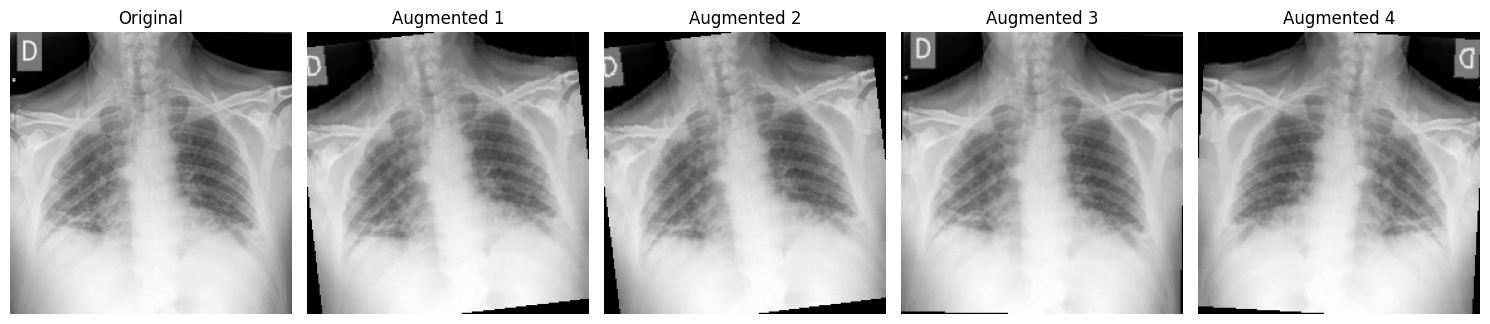

In [ ]:
def show_augmentation_examples(filepath, transform, n=4):
    img = Image.open(filepath).convert("L")

    fig, axes = plt.subplots(1, n + 1, figsize=(15, 4))
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")

    for i in range(n):
        aug = transform(img)
        aug_np = aug.squeeze(0).numpy()
        axes[i+1].imshow(aug_np, cmap="gray")
        axes[i+1].set_title(f"Augmented {i+1}")
        axes[i+1].axis("off")

    plt.tight_layout()
    plt.show()

sample_path = train_df.iloc[0]["filepath"]
show_augmentation_examples(sample_path, train_transform, n=4)

In [ ]:
class CXRDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("L")
        if self.transform:
            img = self.transform(img)
        label = int(row["label"])
        return img, label

In [ ]:
train_dataset = CXRDataset(train_df, transform=train_transform)
val_dataset = CXRDataset(val_df, transform=eval_transform)
test_dataset = CXRDataset(test_df, transform=eval_transform)

class_sample_count = train_df["label"].value_counts().sort_index().values
class_weights = 1.0 / class_sample_count
sample_weights = train_df["label"].map(lambda x: class_weights[x]).values

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Class counts:", class_sample_count)
print("Class weights:", class_weights)

Class counts: [2531 4208 7134  942]
Class weights: [0.0003951  0.00023764 0.00014017 0.00106157]


In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 把第一层改成单通道输入
old_conv = model.conv1
model.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False
)

# 用原来RGB权重的均值初始化单通道卷积核
with torch.no_grad():
    model.conv1.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(CLASS_NAMES))

model = model.to(DEVICE)
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


Linear(in_features=512, out_features=4, bias=True)


In [ ]:
EPOCHS = 10
LR = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [ ]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float("inf")
best_model_path = "best_resnet18_cxr.pth"

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

Epoch [1/10] | Train Loss: 0.2649, Train Acc: 0.9039 | Val Loss: 0.2393, Val Acc: 0.9206
Epoch [2/10] | Train Loss: 0.1579, Train Acc: 0.9439 | Val Loss: 0.2017, Val Acc: 0.9307
Epoch [3/10] | Train Loss: 0.1301, Train Acc: 0.9529 | Val Loss: 0.1944, Val Acc: 0.9351
Epoch [4/10] | Train Loss: 0.1180, Train Acc: 0.9572 | Val Loss: 0.2056, Val Acc: 0.9298
Epoch [5/10] | Train Loss: 0.0946, Train Acc: 0.9669 | Val Loss: 0.1737, Val Acc: 0.9452
Epoch [6/10] | Train Loss: 0.0946, Train Acc: 0.9661 | Val Loss: 0.1726, Val Acc: 0.9405
Epoch [7/10] | Train Loss: 0.0834, Train Acc: 0.9702 | Val Loss: 0.1621, Val Acc: 0.9461
Epoch [8/10] | Train Loss: 0.0772, Train Acc: 0.9717 | Val Loss: 0.1438, Val Acc: 0.9506
Epoch [9/10] | Train Loss: 0.0727, Train Acc: 0.9733 | Val Loss: 0.1913, Val Acc: 0.9436
Epoch [10/10] | Train Loss: 0.0695, Train Acc: 0.9758 | Val Loss: 0.1647, Val Acc: 0.9496


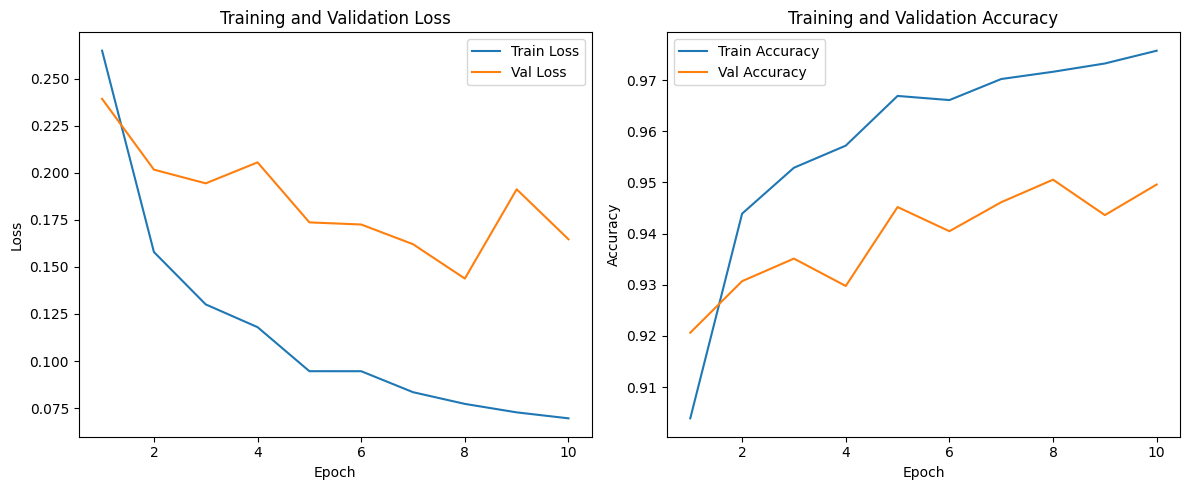

In [ ]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_loss, test_acc, y_true, y_pred, y_prob = evaluate(model, test_loader, criterion, DEVICE)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 4))

Test Loss: 0.1513
Test Accuracy: 0.9483


In [ ]:
precision_macro = precision_score(y_true, y_pred, average="macro")
recall_macro = recall_score(y_true, y_pred, average="macro")
f1_macro = f1_score(y_true, y_pred, average="macro")

precision_weighted = precision_score(y_true, y_pred, average="weighted")
recall_weighted = recall_score(y_true, y_pred, average="weighted")
f1_weighted = f1_score(y_true, y_pred, average="weighted")

# multi-class AUC (one-vs-rest)
y_true_bin = label_binarize(y_true, classes=list(range(len(CLASS_NAMES))))
auc_macro = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
auc_weighted = roc_auc_score(y_true_bin, y_prob, average="weighted", multi_class="ovr")

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1-score (Macro)",
        "Precision (Weighted)",
        "Recall (Weighted)",
        "F1-score (Weighted)",
        "AUC (Macro, OvR)",
        "AUC (Weighted, OvR)"
    ],
    "Value": [
        test_acc,
        precision_macro,
        recall_macro,
        f1_macro,
        precision_weighted,
        recall_weighted,
        f1_weighted,
        auc_macro,
        auc_weighted
    ]
})

print(metrics_df.round(4))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

                 Metric   Value
0              Accuracy  0.9483
1     Precision (Macro)  0.9615
2        Recall (Macro)  0.9566
3      F1-score (Macro)  0.9590
4  Precision (Weighted)  0.9487
5     Recall (Weighted)  0.9483
6   F1-score (Weighted)  0.9485
7      AUC (Macro, OvR)  0.9933
8   AUC (Weighted, OvR)  0.9899

Classification Report:

                 precision    recall  f1-score   support

          COVID     0.9907    0.9779    0.9842       542
   Lung_Opacity     0.9096    0.9257    0.9176       902
         Normal     0.9508    0.9477    0.9492      1529
Viral Pneumonia     0.9949    0.9752    0.9850       202

       accuracy                         0.9483      3175
      macro avg     0.9615    0.9566    0.9590      3175
   weighted avg     0.9487    0.9483    0.9485      3175



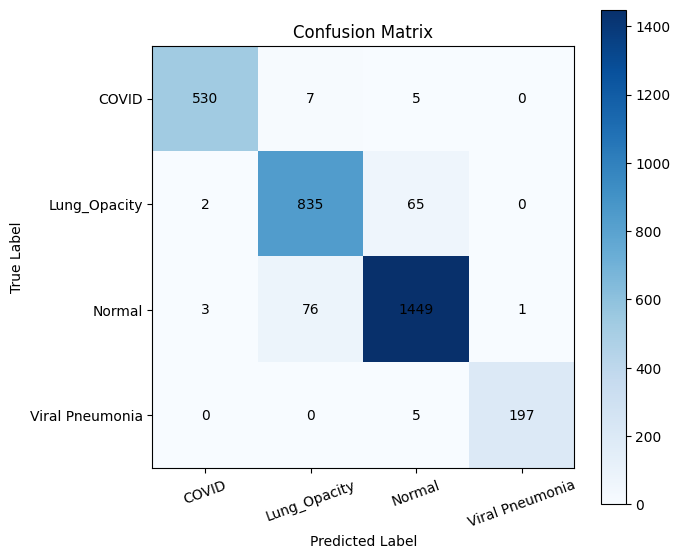

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(CLASS_NAMES))
plt.xticks(tick_marks, CLASS_NAMES, rotation=20)
plt.yticks(tick_marks, CLASS_NAMES)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [ ]:
# ===== Overall metrics =====
accuracy = accuracy_score(y_true, y_pred)

precision_macro = precision_score(y_true, y_pred, average="macro")
recall_macro = recall_score(y_true, y_pred, average="macro")
f1_macro = f1_score(y_true, y_pred, average="macro")

precision_weighted = precision_score(y_true, y_pred, average="weighted")
recall_weighted = recall_score(y_true, y_pred, average="weighted")
f1_weighted = f1_score(y_true, y_pred, average="weighted")

# ===== Multi-class AUC (One-vs-Rest) =====
y_true_bin = label_binarize(y_true, classes=list(range(len(CLASS_NAMES))))

auc_macro_ovr = roc_auc_score(
    y_true_bin, y_prob,
    average="macro",
    multi_class="ovr"
)

auc_weighted_ovr = roc_auc_score(
    y_true_bin, y_prob,
    average="weighted",
    multi_class="ovr"
)

# ===== Overall metrics table =====
metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1-score (Macro)",
        "Precision (Weighted)",
        "Recall (Weighted)",
        "F1-score (Weighted)",
        "AUC (Macro, OvR)",
        "AUC (Weighted, OvR)"
    ],
    "Value": [
        accuracy,
        precision_macro,
        recall_macro,
        f1_macro,
        precision_weighted,
        recall_weighted,
        f1_weighted,
        auc_macro_ovr,
        auc_weighted_ovr
    ]
})

print("===== Overall Metrics =====")
print(metrics_df.round(4))

# ===== Per-class metrics =====
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).T
print("\n===== Classification Report =====")
print(report_df.round(4))

# ===== Optional: per-class AUC =====
per_class_auc = {}
for i, class_name in enumerate(CLASS_NAMES):
    per_class_auc[class_name] = roc_auc_score(y_true_bin[:, i], y_prob[:, i])

per_class_auc_df = pd.DataFrame({
    "Class": list(per_class_auc.keys()),
    "AUC (OvR)": list(per_class_auc.values())
})

print("\n===== Per-Class AUC =====")
print(per_class_auc_df.round(4))

===== Overall Metrics =====
                 Metric   Value
0              Accuracy  0.9483
1     Precision (Macro)  0.9615
2        Recall (Macro)  0.9566
3      F1-score (Macro)  0.9590
4  Precision (Weighted)  0.9487
5     Recall (Weighted)  0.9483
6   F1-score (Weighted)  0.9485
7      AUC (Macro, OvR)  0.9933
8   AUC (Weighted, OvR)  0.9899

===== Classification Report =====
                 precision  recall  f1-score    support
COVID               0.9907  0.9779    0.9842   542.0000
Lung_Opacity        0.9096  0.9257    0.9176   902.0000
Normal              0.9508  0.9477    0.9492  1529.0000
Viral Pneumonia     0.9949  0.9752    0.9850   202.0000
accuracy            0.9483  0.9483    0.9483     0.9483
macro avg           0.9615  0.9566    0.9590  3175.0000
weighted avg        0.9487  0.9483    0.9485  3175.0000

===== Per-Class AUC =====
             Class  AUC (OvR)
0            COVID     0.9997
1     Lung_Opacity     0.9859
2           Normal     0.9876
3  Viral Pneumonia    